In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

In [2]:
df = pd.read_csv('Huntington_Disease_Dataset.csv')



In [3]:
# Step 1 to remove duplicate from dataset
print (df.duplicated().sum())
df.drop_duplicates(inplace=True)

0


In [4]:
# Step 2 to drop unnecessary column because it efect teh functionality of data and also make it difficult to train the model
df.drop(columns=['Patient_ID', 'Random_Protein_Sequence', 'Random_Gene_Sequence'], inplace=True)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['Age', 'Sex', 'Family_History', 'HTT_CAG_Repeat_Length', 'Motor_Symptoms', 'Cognitive_Decline', 'Chorea_Score', 'Brain_Volume_Loss', 'Functional_Capacity', 'Gene_Mutation_Type', 'HTT_Gene_Expression_Level', 'Protein_Aggregation_Level', 'Disease_Stage', 'Gene/Factor', 'Chromosome_Location', 'Function', 'Effect', 'Category']


In [5]:
# step 4 handle and remove null value
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [6]:
#step 5 is to convert object into numeric value by using label encoding because there are multiple object value so we use loop for it
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype=='object':
      df[col]=le.fit_transform( df[col])




In [7]:
#step 6 is standarization
cols_to_scale = [
    'Age', 'HTT_CAG_Repeat_Length', 'Chorea_Score',
    'Brain_Volume_Loss', 'Functional_Capacity',
    'HTT_Gene_Expression_Level', 'Protein_Aggregation_Level'
]

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df.head()

,Age,Sex,Family_History,HTT_CAG_Repeat_Length,Motor_Symptoms,Cognitive_Decline,Chorea_Score,Brain_Volume_Loss,Functional_Capacity,Gene_Mutation_Type,HTT_Gene_Expression_Level,Protein_Aggregation_Level,Disease_Stage,Gene/Factor,Chromosome_Location,Function,Effect,Category
0,-1.637068,1,0,0.761300,1,2,1.315684,-1.120049,1.529313,0,0.520467,-1.373254,2,0,1,1,2,1
1,-1.502153,0,1,-1.449477,2,1,-0.615817,0.374766,-0.003079,3,-1.643556,-1.571002,3,0,1,1,2,1
2,0.926318,1,1,-1.525711,2,1,-1.390502,-1.324376,0.658636,1,-0.597854,-1.048383,0,3,2,2,0,2
3,0.723945,1,1,-0.534673,0,2,-0.626239,0.799551,0.902425,0,-0.220239,-0.462204,3,3,2,2,0,2
4,-0.827578,0,1,-0.687140,1,0,-0.938892,1.208205,0.693463,2,0.781892,0.293474,1,1,1,0,1,0


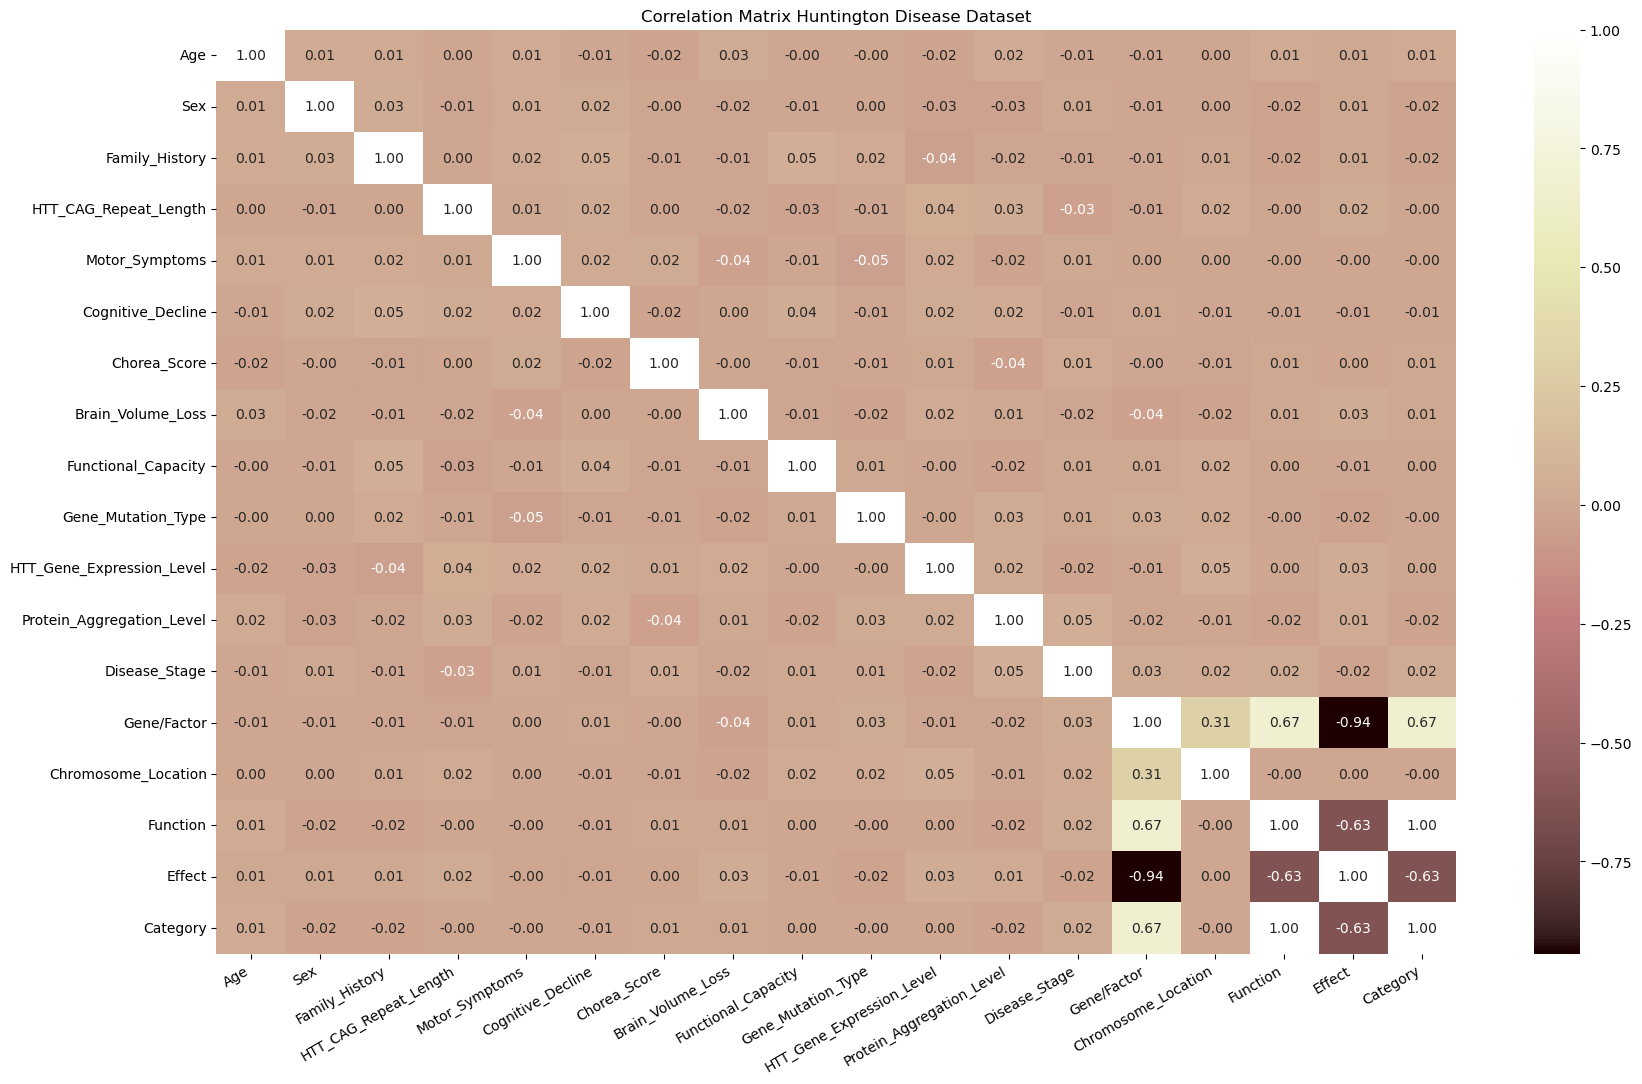

In [8]:
#step 7 is correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(20,12))
sns.heatmap(corr_matrix,annot=True,cmap='pink',fmt='.2f')
plt.title('Correlation Matrix Huntington Disease Dataset')
plt.xticks(rotation=30,ha='right')
plt.show()

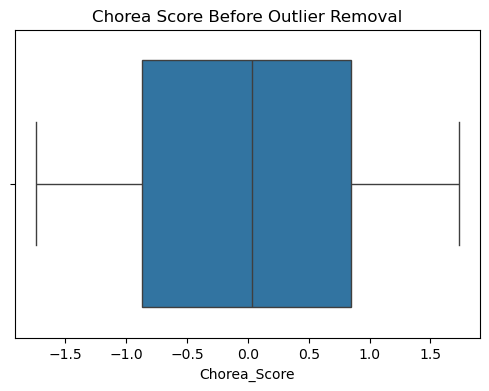

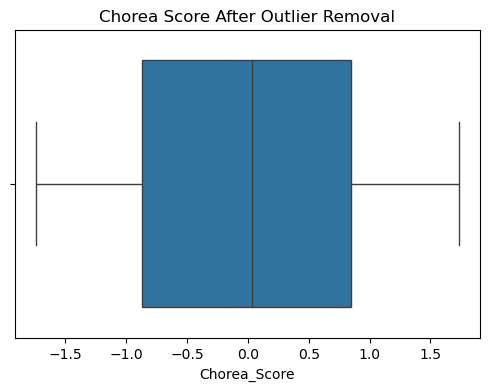

In [9]:
# step 8 is to remove outlier
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Chorea_Score'])
plt.title('Chorea Score Before Outlier Removal')
plt.show()

Q1 = df['Chorea_Score'].quantile(0.25)
Q3 = df['Chorea_Score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Chorea_Score'] >= lower_bound) & (df['Chorea_Score'] <= upper_bound)]

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Chorea_Score'])
plt.title('Chorea Score After Outlier Removal')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_21368\3318714486.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Disease_Stage', y='HTT_CAG_Repeat_Length', data=df, palette='muted', inner='quartile')


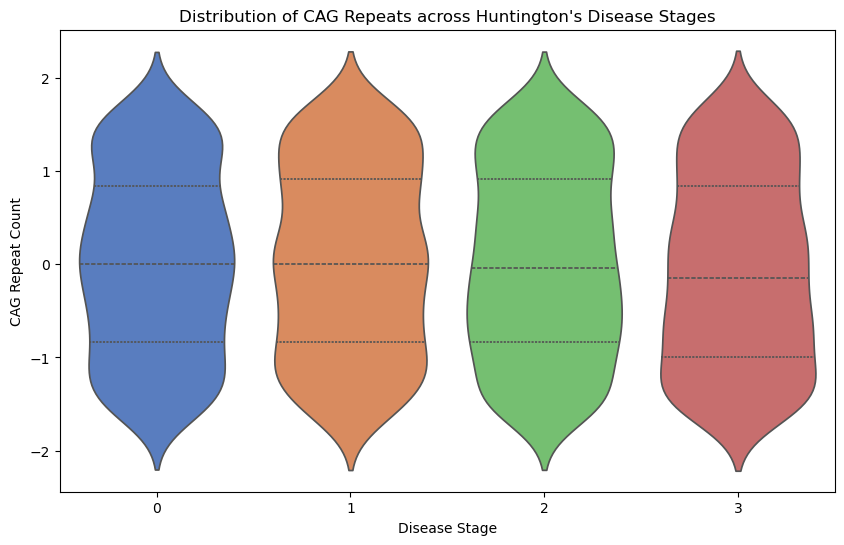

In [10]:
#violin plot
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.violinplot(x='Disease_Stage', y='HTT_CAG_Repeat_Length', data=df, palette='muted', inner='quartile')
plt.title('Distribution of CAG Repeats across Huntington\'s Disease Stages')
plt.xlabel('Disease Stage')
plt.ylabel('CAG Repeat Count')
plt.show()

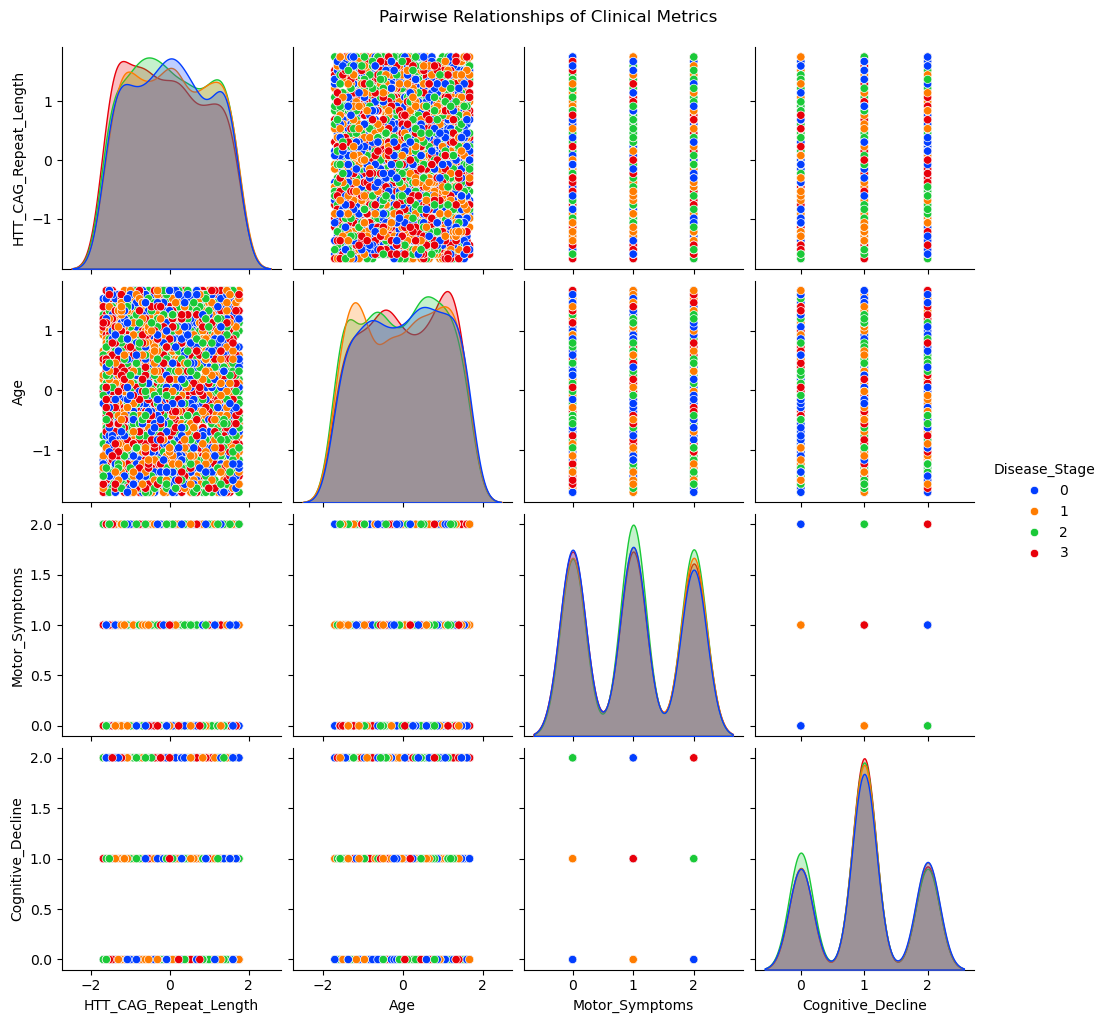

In [11]:
# pair plot
import seaborn as sns
import matplotlib.pyplot as plt
features = ['HTT_CAG_Repeat_Length', 'Age', 'Motor_Symptoms', 'Cognitive_Decline', 'Disease_Stage']
sns.pairplot(df[features], hue='Disease_Stage', palette='bright', diag_kind='kde')
plt.suptitle('Pairwise Relationships of Clinical Metrics', y=1.02)
plt.show()

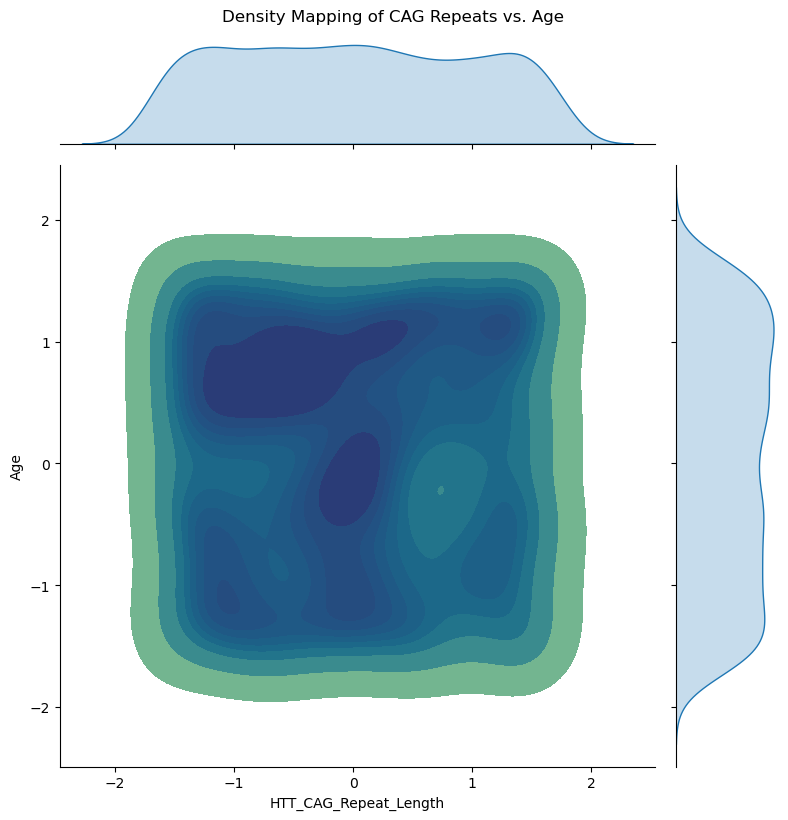

In [12]:
#KDE
import seaborn as sns
import matplotlib.pyplot as plt
sns.jointplot(x='HTT_CAG_Repeat_Length', y='Age', data=df, kind='kde', cmap='crest', fill=True, height=8)
plt.gcf().suptitle('Density Mapping of CAG Repeats vs. Age', y=1.02)
plt.show()

> **Recovery note:** This notebook was rebuilt from a truncated file. The 13th cell (a Plotly chart) was lost because its large interactive output made the saved file exceed 1 MB and it got cut off mid-save. All code above (cells 1–12) is intact. To avoid this again, run `Cell → All Output → Clear` before saving, or use `fig.show(renderer='png')` instead of interactive Plotly output.